In [ ]:
# Import necessary libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner.tuners import RandomSearch
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta

In [29]:
# Download Harga Saham BCA di Yahoo Finance
ticker = 'BBCA.JK'
data = yf.download(ticker, start='2023-01-01', end='2025-01-01')

# Select only the 'Close' column for prediction
data = data[['Close']]

# Normalize Data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

[*********************100%***********************]  1 of 1 completed


In [30]:
# Function to create a dataset with time steps
def create_dataset(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

# Calculate time_steps as a fraction of the dataset length
time_steps = int(len(data)*0.2)  # Use 20% of the dataset length as time steps
split_ratio = 0.8

# Create dataset with time steps
X, y = create_dataset(data_scaled,time_steps)

# Split dataset into train and test data
split = int(split_ratio * len(data))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [31]:
# Define the model builder function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=50, max_value=200, step=50),
                   return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(LSTM(units=hp.Int('units', min_value=50, max_value=200, step=50)))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [32]:
# Define the tuner and perform hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5, 
    executions_per_trial=1,
    directory='keras_tuner_logs',
    project_name='prediksi_harga_saham_BCA')

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

Trial 4 Complete [00h 00m 21s]
val_loss: 0.005104781594127417

Best val_loss So Far: 0.0042150202207267284
Total elapsed time: 00h 02m 12s


In [33]:
# Get the best hyperparameters and build the best model
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train the best model
history = best_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - loss: 0.1053 - val_loss: 0.0434
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.0111 - val_loss: 0.0119
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 428ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 575ms/step - loss: 0.0039 - val_loss: 0.0088
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - loss: 0.0032 - val_loss: 0.0051
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 374ms/step - loss: 0.0028 - val_loss: 0.0047
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.0024 - val_loss: 0.0045
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - loss: 0.0022 - val_loss: 0.0051
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.0024 - val_loss: 0.0047
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 502ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - loss: 0.0024 - val_loss: 0.0045
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2

In [39]:
# Predict stock prices
predictions = best_model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(data[-len(predictions):], predictions))
print(f'Root Mean Squared Error: {rmse:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Root Mean Squared Error: 143.64


In [35]:
# Predict the next 3 months
future_steps = 90  # Approx. 3 months
last_sequence = data_scaled[-time_steps:]  # Last available sequence from the data

future_predictions = []

for _ in range(future_steps):
    next_pred = best_model.predict(last_sequence.reshape(1, time_steps, 1))
    future_predictions.append(next_pred[0, 0])
    last_sequence = np.append(last_sequence[1:], next_pred, axis=0)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates
last_date = data.index[-1]
future_dates = [last_date + timedelta(days=i) for i in range(1, future_steps + 1)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

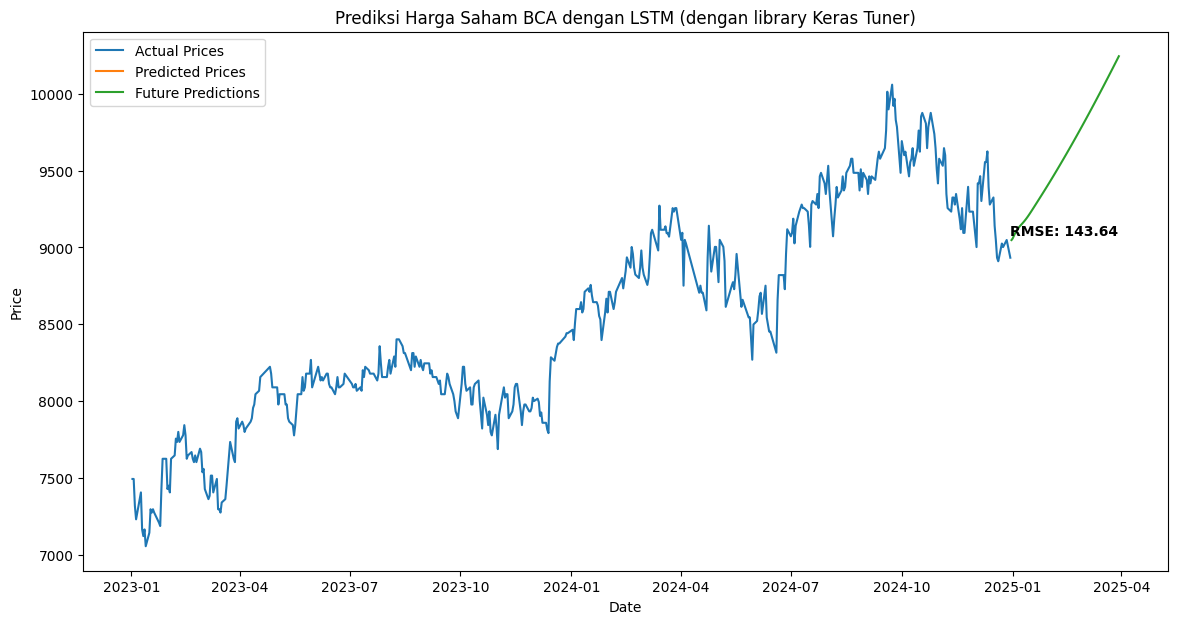

In [38]:
# Visualize the results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data, label='Actual Prices')
plt.plot(data.index[-len(predictions):], predictions, label='Predicted Prices')
plt.plot(future_dates, future_predictions, label='Future Predictions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Prediksi Harga Saham BCA dengan LSTM (dengan library Keras Tuner)')
plt.legend()

# Add RMSE to the plot
plt.text(data.index[-1], predictions[-1], f'RMSE: {rmse:.2f}', horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.show()